In [1]:
from movement.io import load_poses
from movement.plots import plot_centroid_trajectory

In [2]:
file_path = "/Users/annateruel/Desktop/IMG_2990_predictions_bottomup_v2.h5"

In [4]:
ds = load_poses.from_sleap_file(file_path, fps=30)
print(ds)

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 17429, space: 2, keypoints: 7, individuals: 4)
Coordinates:
  * time         (time) float64 139kB 0.0 0.03333 0.06667 ... 580.9 580.9 580.9
  * space        (space) <U1 8B 'x' 'y'
  * keypoints    (keypoints) <U8 224B 'nose' 'rightear' ... 'leftpaw' 'tailbase'
  * individuals  (individuals) <U7 112B 'track_0' 'track_1' 'track_2' 'track_3'
Data variables:
    position     (time, space, keypoints, individuals) float32 4MB 423.6 ... ...
    confidence   (time, keypoints, individuals) float32 2MB 0.8559 ... 0.8838
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              30.0
    time_unit:        seconds
    source_file:      /Users/annateruel/Desktop/IMG_2990_predictions_bottomup...


In [16]:
rat1 = ds.sel(individuals="track_0", keypoints="nose")
print(rat1)

<xarray.Dataset> Size: 349kB
Dimensions:      (time: 17429, space: 2)
Coordinates:
  * time         (time) float64 139kB 0.0 0.03333 0.06667 ... 580.9 580.9 580.9
  * space        (space) <U1 8B 'x' 'y'
    keypoints    <U8 32B 'nose'
    individuals  <U7 28B 'track_0'
Data variables:
    position     (time, space) float32 139kB 423.6 915.6 423.7 ... 884.1 196.5
    confidence   (time) float32 70kB 0.8559 0.8678 0.8668 ... 0.8596 0.8566
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              30.0
    time_unit:        seconds
    source_file:      /Users/annateruel/Desktop/IMG_2990_predictions_bottomup...


In [17]:
position = rat1.position
print(position)

<xarray.DataArray 'position' (time: 17429, space: 2)> Size: 139kB
423.6 915.6 423.7 920.2 420.2 924.4 ... 884.2 199.8 884.2 195.9 884.1 196.5
Coordinates:
  * time         (time) float64 139kB 0.0 0.03333 0.06667 ... 580.9 580.9 580.9
  * space        (space) <U1 8B 'x' 'y'
    keypoints    <U8 32B 'nose'
    individuals  <U7 28B 'track_0'


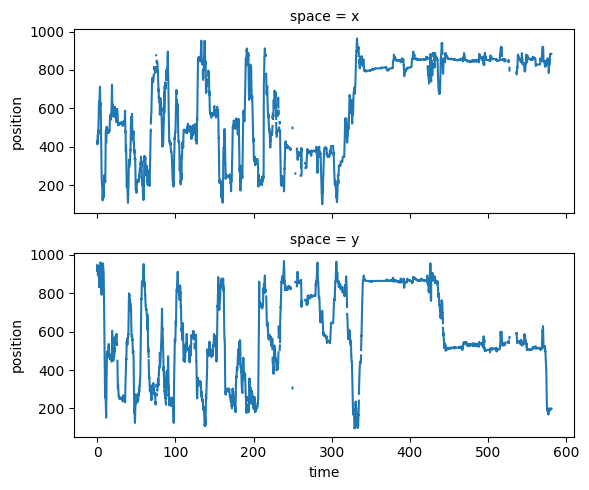

In [18]:
position.plot.line(x="time", row="space", aspect=2, size=2.5)

2026-05-10 20:11:44.841 | WARNING  | matplotlib._api:warn_external:405 - /var/folders/q4/d9bmvghd77x_l961kcngf8_c0000gn/T/ipykernel_9057/2646425995.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



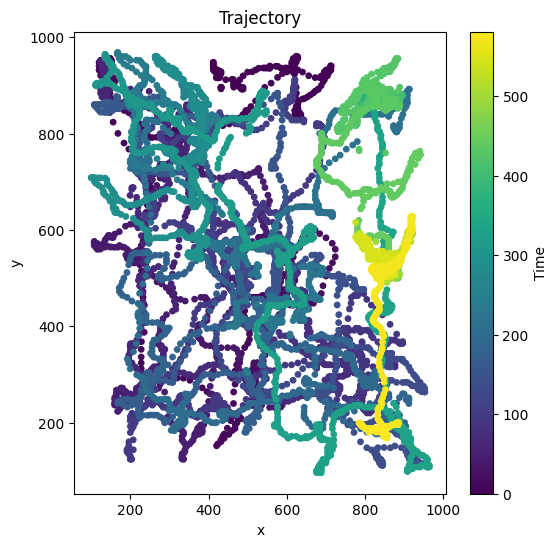

In [20]:
mouse_name = "track_0"
fig, ax = plot_centroid_trajectory(position, individual=mouse_name)
fig.show()